# Advanced Business Analysis

## Objective

The objective of this notebook is to perform advanced business analysis on the cleaned Superstore dataset. This analysis focuses on category performance, sub-category performance, shipping analysis, regional profitability, discount impact, order quantity analysis, and strategic business recommendations to support better decision-making.

# Dataset Loading

In this section, we import the required Python libraries and load the cleaned dataset generated during the data cleaning phase.

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/processed/clean_superstore.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Year,Order Month,Order Month Name,Order Quarter
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,November,4
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,November,4
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,June,2
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,October,4
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,October,4


# Category Performance Analysis

Analyze sales, profit, and average discount for each product category to understand overall business performance across categories.

## Business Insight

- Compare sales and profit across all product categories.
- Identify categories generating high revenue but low profit.
- Categories with high profitability should receive greater marketing investment.

In [19]:
category_analysis = (
    df.groupby("Category")
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum"),
          Average_Discount=("Discount", "mean")
      )
      .sort_values("Total_Sales", ascending=False)
)

category_analysis

,Total_Sales,Total_Profit,Average_Discount
Category,,,
Technology,836154.0330,145454.9481,0.132323
Furniture,741999.7953,18451.2728,0.173923
Office Supplies,719047.0320,122490.8008,0.157285


# Sales and Profit Visualization

Visualize total sales and total profit by category to compare category performance.

## Business Insight

- Determine whether the highest-selling category is also the most profitable.
- Use this information for product portfolio optimization.

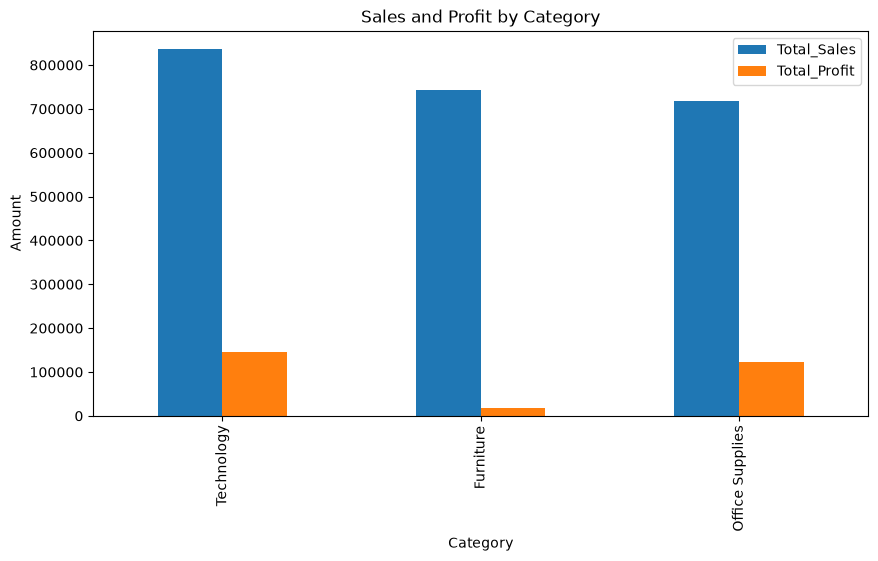

In [20]:
category_analysis[["Total_Sales", "Total_Profit"]].plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Sales and Profit by Category")
plt.ylabel("Amount")

plt.show()

# Sub-Category Analysis

Analyze product performance at the sub-category level to identify top-performing and underperforming product groups.

## Business Insight

- Identify sub-categories generating maximum revenue.
- Recognize low-performing sub-categories for improvement.
- Product-level optimization begins with sub-category analysis.

In [21]:
subcategory = (
    df.groupby("Sub-Category")
      .agg(
          Sales=("Sales","sum"),
          Profit=("Profit","sum")
      )
      .sort_values("Sales", ascending=False)
)

subcategory

,Sales,Profit
Sub-Category,,
Phones,330007.0540,44515.7306
Chairs,328449.1030,26590.1663
Storage,223843.6080,21278.8264
Tables,206965.5320,-17725.4811
Binders,203412.7330,30221.7633
Machines,189238.6310,3384.7569
Accessories,167380.3180,41936.6357
Copiers,149528.0300,55617.8249
Bookcases,114879.9963,-3472.5560


# Sales by Sub-Category

Visualize total sales generated by each product sub-category.

## Business Insight

- High-selling sub-categories deserve higher inventory levels.
- Seasonal demand should also be considered.

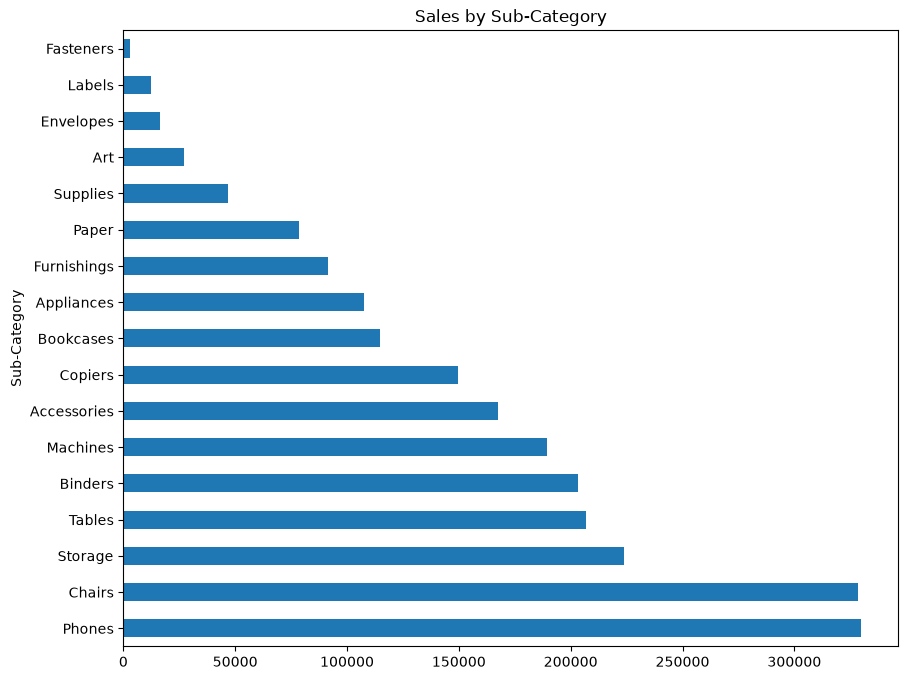

In [22]:
subcategory["Sales"].plot(
    kind="barh",
    figsize=(10,8)
)

plt.title("Sales by Sub-Category")

plt.show()

# Profit by Sub-Category

Analyze profitability across different sub-categories.

## Business Insight

- Some sub-categories may generate losses despite strong sales.
- Pricing and discount strategies should be reviewed for loss-making products.

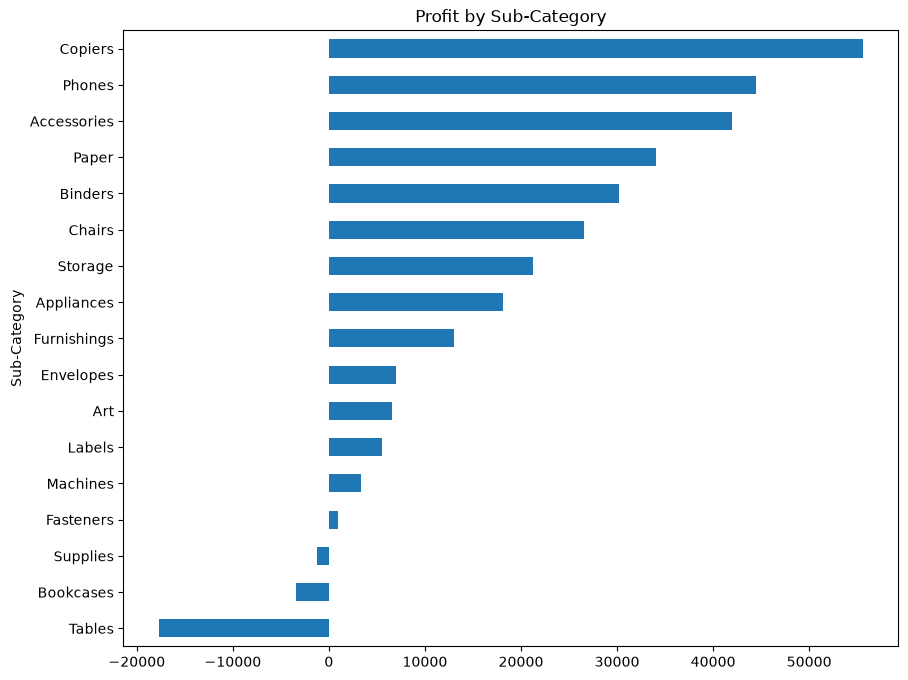

In [23]:
subcategory["Profit"].sort_values().plot(
    kind="barh",
    figsize=(10,8)
)

plt.title("Profit by Sub-Category")

plt.show()

# Shipping Analysis

Analyze business performance based on shipping mode.

## Business Insight

- Compare sales and profit across shipping methods.
- Determine whether faster shipping methods generate higher revenue.

In [24]:
ship = (
    df.groupby("Ship Mode")
      .agg(
          Sales=("Sales","sum"),
          Profit=("Profit","sum")
      )
)

ship

,Sales,Profit
Ship Mode,,
First Class,3.514284e+05,48969.8399
Same Day,1.283631e+05,15891.7589
Second Class,4.591936e+05,57446.6354
Standard Class,1.358216e+06,164088.7875


# Shipping Mode Visualization

Visualize sales and profit by shipping mode.

## Business Insight

- Standard Class generally handles the largest number of orders.
- Premium shipping options may generate higher profit per order.

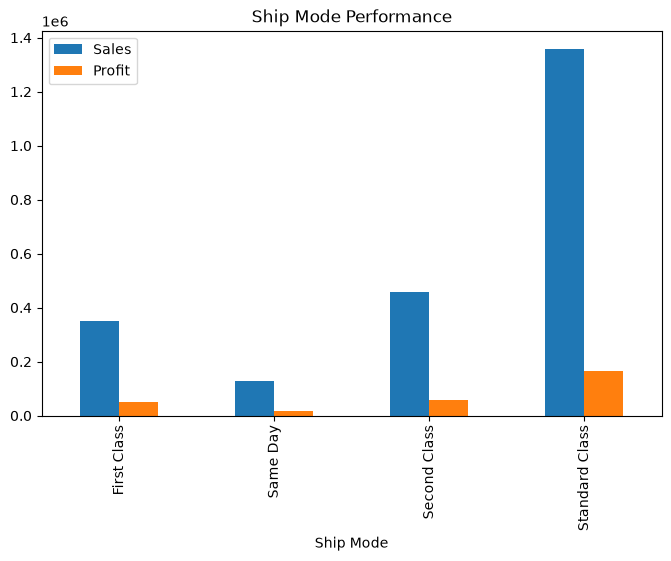

In [25]:
ship.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Ship Mode Performance")

plt.show()

# State Profitability Analysis

Evaluate profit generated by each state to identify strong and weak business regions.

## Business Insight

- Identify states contributing the highest profit.
- Identify states consistently generating losses.
- Regional strategies should differ based on profitability.

In [26]:
state_profit = (
    df.groupby("State")["Profit"]
      .sum()
      .sort_values()
)

state_profit.head(10)

State
Texas            -25729.3563
Ohio             -16971.3766
Pennsylvania     -15559.9603
Illinois         -12607.8870
North Carolina    -7490.9122
Colorado          -6527.8579
Tennessee         -5341.6936
Arizona           -3427.9246
Florida           -3399.3017
Oregon            -1190.4705
Name: Profit, dtype: float64

# Top Profitable States

Visualize the states generating the highest profits.

## Business Insight

- High-profit states should remain a strategic business priority.
- Additional marketing investment may increase market share.

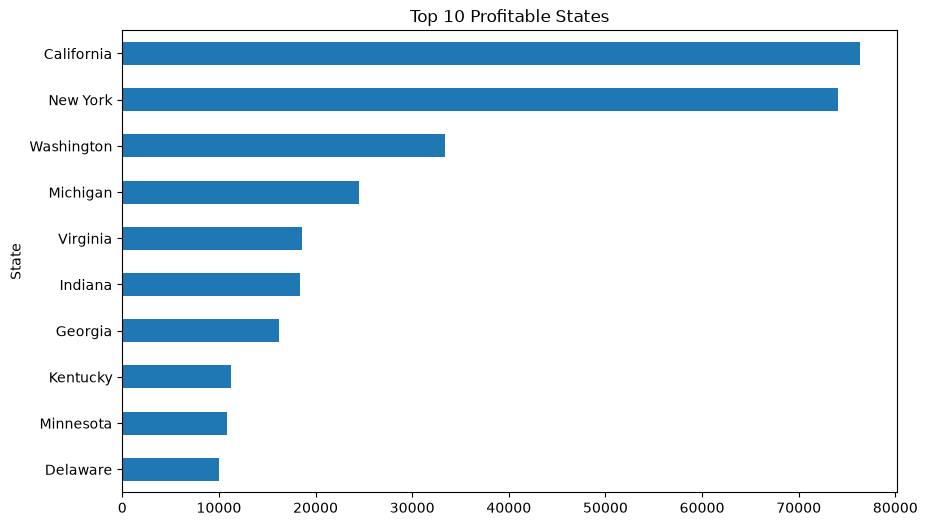

In [27]:
state_profit.tail(10).plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Top 10 Profitable States")

plt.show()

# Least Profitable States

Visualize the states generating the lowest profits.

## Business Insight

- Investigate pricing, logistics, and customer demand in low-profit states.
- Business expansion should consider profitability instead of sales alone.

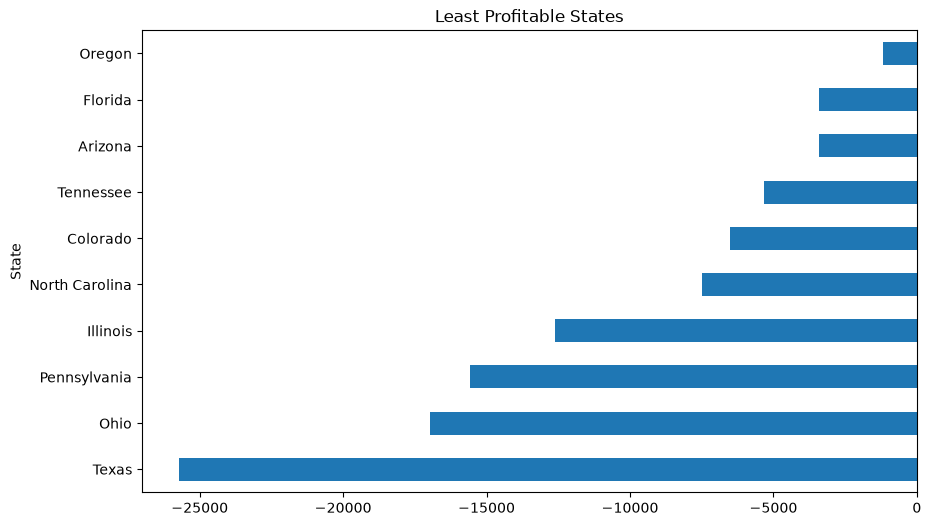

In [28]:
state_profit.head(10).plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Least Profitable States")

plt.show()

# Discount Analysis

Analyze how discounts influence average sales and profitability.

## Business Insight

- Excessive discounts can significantly reduce profit margins.
- Discount policies should balance revenue growth and profitability.

In [29]:
discount = (
    df.groupby("Discount")
      .agg(
          Average_Profit=("Profit","mean"),
          Average_Sales=("Sales","mean")
      )
)

discount

,Average_Profit,Average_Sales
Discount,,
0.00,66.900292,226.742074
0.10,96.055074,578.397351
0.15,27.288298,529.971567
0.20,24.702572,209.076940
0.30,-45.679636,454.742974
0.32,-88.560656,536.794770
0.40,-111.927429,565.134874
0.45,-226.646464,498.634000
0.50,-310.703456,892.705152


# Discount vs Average Profit

Visualize the relationship between discounts and average profit.

## Business Insight

- Profit typically decreases as discounts increase.
- Controlled discount strategies can improve long-term profitability.

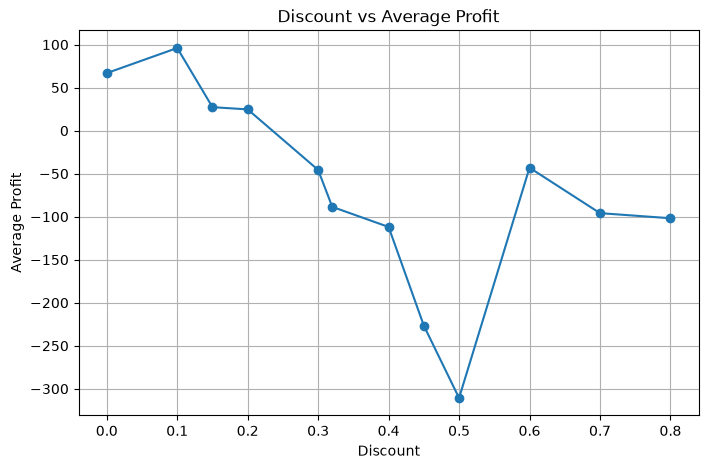

In [30]:
plt.figure(figsize=(8,5))

plt.plot(
    discount.index,
    discount["Average_Profit"],
    marker="o"
)

plt.title("Discount vs Average Profit")

plt.xlabel("Discount")

plt.ylabel("Average Profit")

plt.grid(True)

plt.show()

# Order Quantity Analysis

Analyze how order quantity affects total sales and profit.

## Business Insight

- Larger order quantities may generate higher sales.
- Profitability should also be evaluated alongside quantity.

In [31]:
quantity = (
    df.groupby("Quantity")
      .agg(
          Sales=("Sales","sum"),
          Profit=("Profit","sum")
      )
)

quantity

,Sales,Profit
Quantity,,
1,53251.9345,7440.4801
2,289091.4798,38448.4088
3,422060.6007,57015.5250
4,323670.9944,44223.3908
5,415661.6965,49516.5945
6,207122.3214,10325.4678
7,239908.3659,34286.9730
8,117760.1760,10856.7960
9,128505.5901,17687.8908


# Quantity Performance Visualization

Visualize sales and profit across different order quantities.

## Business Insight

- Determine the most profitable order quantity.
- Optimize inventory based on demand patterns.

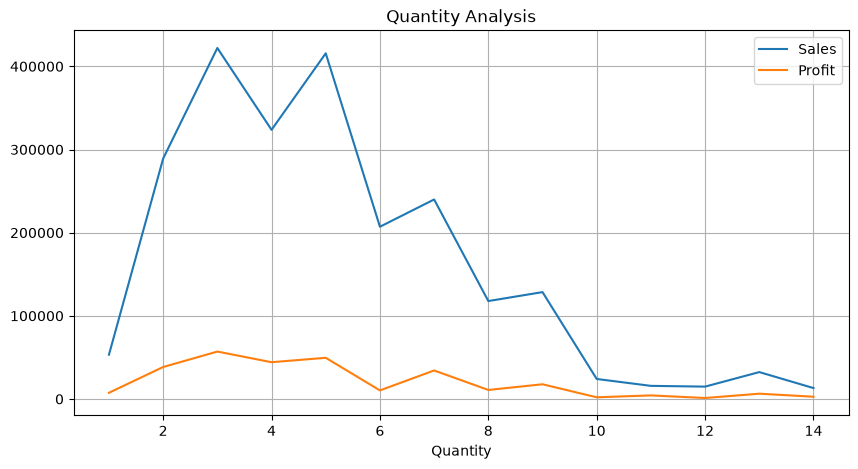

In [32]:
quantity.plot(
    figsize=(10,5)
)

plt.title("Quantity Analysis")

plt.grid(True)

plt.show()

# Regional Business Dashboard

Summarize regional performance using sales, profit, and order count.

## Business Insight

- Compare overall business performance across regions.
- Regions with strong sales and profit should receive continued investment.

In [33]:
dashboard = (
    df.groupby("Region")
      .agg(
          Sales=("Sales","sum"),
          Profit=("Profit","sum"),
          Orders=("Order ID","count")
      )
)

dashboard

,Sales,Profit,Orders
Region,,,
Central,501239.8908,39706.3625,2323
East,678781.2400,91522.7800,2848
South,391721.9050,46749.4303,1620
West,725457.8245,108418.4489,3203


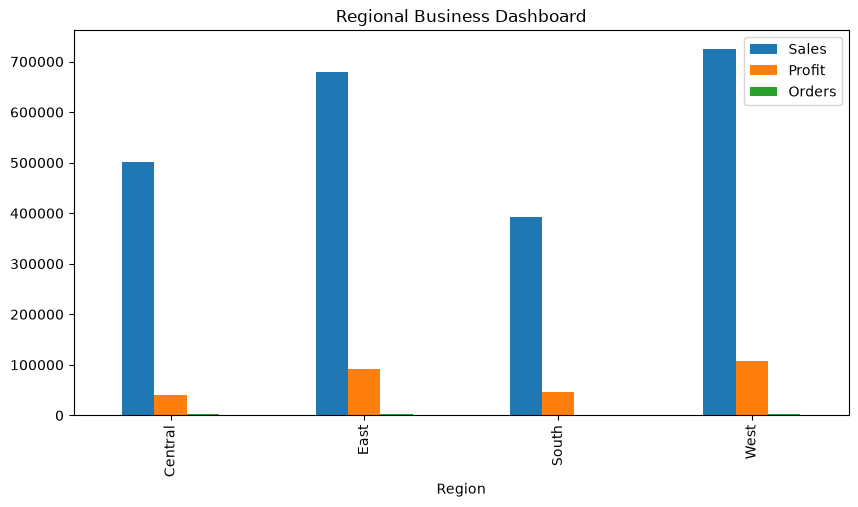

In [34]:
dashboard.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Regional Business Dashboard")

plt.show()

# Final Business Recommendations

## Key Findings

- Technology remains the strongest business category.
- Several sub-categories generate losses despite high sales.
- Standard Class shipping handles the majority of customer orders.
- Some states consistently underperform in profitability.
- High discounts negatively affect profit margins.
- Regional performance varies significantly.

## Recommendations

- Increase investment in profitable categories and regions.
- Review pricing strategies for low-profit products.
- Optimize discount policies.
- Improve business performance in underperforming states.
- Expand marketing efforts toward profitable customer segments.
- Maintain sufficient inventory for high-performing products.

# Notebook Summary

## Tasks Completed

- Loaded cleaned dataset
- Performed category analysis
- Performed sub-category analysis
- Analyzed shipping performance
- Evaluated state profitability
- Studied discount impact
- Analyzed order quantity
- Built a regional business dashboard
- Generated business insights
- Proposed strategic recommendations